In [67]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2 
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D,Dropout,BatchNormalization,Activation
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from keras.layers import Conv2D
import numpy as np
import matplotlib.pyplot as plt
import os
import glob as gb
import cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Load MobileNetV2 with pre-trained weights (on ImageNet)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(240, 240, 3), alpha=0.5)

# Freeze the layers of the base model so they aren't updated during the training
base_model.trainable = False

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_17992\59620146.py:17: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(240, 240, 3), alpha=0.5)


In [68]:


# Add a global average pooling layer
x = base_model.output

# Add a Conv2D layer
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)  # Added Conv2D layer
x = BatchNormalization()(x)  # Optional BatchNormalization after Conv2D
x = Dropout(0.3)(x)  # Dropout to reduce overfitting

# Add a global average pooling layer after convolution
x = GlobalAveragePooling2D()(x)

# Add more fully connected layers with batch normalization and adjusted units
x = Dense(64, kernel_regularizer=l2(0.001))(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(0.5)(x)

x = Dense(32, kernel_regularizer=l2(0.001))(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(0.5)(x)

x = Dense(16, kernel_regularizer=l2(0.001))(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)

# Output layer for binary classification (sigmoid for binary classification)
outputs = Dense(1, activation='sigmoid')(x)

# Create the final model
model = Model(inputs=base_model.input, outputs=outputs)

# Compile the model with binary crossentropy and accuracy metrics
model.compile(optimizer=Adam(learning_rate=1e-3), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 240, 240,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 120, 120,  │        432 │ input_layer_5[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 120, 120,  │         64 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 120, 120,  │          0 │ bn_Conv1[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 120, 120,  │        144 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 120, 120,  │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 120, 120,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 120, 120,  │        128 │ expanded_conv_de… │
│ (Conv2D)            │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 120, 120,  │         32 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 120, 120,  │        384 │ expanded_conv_pr… │
│ (Conv2D)            │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 120, 120,  │        192 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 120, 120,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 121, 121,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 60, 60,    │        432 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 60, 60,    │        192 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 60, 60,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 60, 60,    │        768 │ block_1_depthwis

 Total params: 1,080,209 (4.12 MB)

 Trainable params: 373,697 (1.43 MB)

 Non-trainable params: 706,512 (2.70 MB)

In [69]:
# Get the current working directory (main directory of the script)
main_dir = os.getcwd()

# Construct the paths relative to the main directory
train_path = os.path.join(main_dir, 'dataset', 'train')
test_path = os.path.join(main_dir, 'dataset', 'test')
val_path = os.path.join(main_dir, 'dataset', 'val')

In [70]:
# Get the current working directory
current_dir = os.getcwd()

# Go one step back
main_dir = os.path.dirname(current_dir)

In [71]:

# Construct the paths relative to the main directory
train_path = os.path.join(main_dir, 'dataset', 'train')
test_path = os.path.join(main_dir, 'dataset', 'test')
val_path = os.path.join(main_dir, 'dataset', 'val')
for folder in os.listdir(train_path):
    images=gb.glob(pathname=train_path + '/' +folder+'/*')
    print(f'for training data, we found {len(images)} in folder {folder}')
for folder in os.listdir(test_path):
    images=gb.glob(pathname=test_path + '/' +folder+'/*')
    print(f'for testing data, we found {len(images)} in folder {folder}')
for folder in os.listdir(val_path):
    images=gb.glob(pathname=val_path + '/' +folder+'/*')
    print(f'for val data, we found {len(images)} in folder {folder}')
code={"clean":0,"dirty":1}

for training data, we found 750 in folder clean
for training data, we found 811 in folder dirty
for testing data, we found 100 in folder clean
for testing data, we found 100 in folder dirty
for val data, we found 100 in folder clean
for val data, we found 99 in folder dirty


In [72]:
# size=[]

# for folder in os.listdir(train_path):
#     images=gb.glob(pathname=train_path + '/' +folder+'/*.jpg')
#     for img in images:
#       image=plt.imread(img)
#       size.append(image.shape)
#

In [73]:
def normalize_image(image):
    """Normalize the image to range [-1, 1]."""
    image = image.astype(np.float32)  # Convert to float32 for division
    image = (image / 127.5) - 1.0  # Normalize to [-1, 1]
    return image

In [74]:
x_train = []
y_train = []

# Load and normalize training data
for folder in os.listdir(train_path):
    images = gb.glob(pathname=train_path + '/' + folder + '/*')
    
    for img in images:
        try:
            image = cv2.imread(img)
            if image is not None:
                image = cv2.resize(image, (240, 240))  # Resize to (240, 240)
                image = normalize_image(image)  # Normalize to [-1, 1]
                x_train.append(image)
                y_train.append(code[folder])
        except Exception as e:
            print(f"Error loading image {img}: {e}")

x_test = []
y_test = []

# Load and normalize testing data
for folder in os.listdir(test_path):
    images = gb.glob(pathname=test_path + '/' + folder + '/*')
    
    for img in images:
        try:
            image = cv2.imread(img)
            if image is not None:
                image = cv2.resize(image, (240, 240))  # Resize to (240, 240)
                image = normalize_image(image)  # Normalize to [-1, 1]
                x_test.append(image)
                y_test.append(code[folder])
        except Exception as e:
            print(f"Error loading image {img}: {e}")

x_val = []
y_val = []

# Load and normalize validation data
for folder in os.listdir(val_path):
    images = gb.glob(pathname=val_path + '/' + folder + '/*')
    
    for img in images:
        try:
            image = cv2.imread(img)
            if image is not None:
                image = cv2.resize(image, (240, 240))  # Resize to (240, 240)
                image = normalize_image(image)  # Normalize to [-1, 1]
                x_val.append(image)
                y_val.append(code[folder])
        except Exception as e:
            print(f"Error loading image {img}: {e}")


In [75]:
# Converting lists to numpy arrays for training
x_train = np.array(x_train)
y_train = np.array(y_train)
x_test = np.array(x_test)
y_test = np.array(y_test)
x_val = np.array(x_val)
y_val = np.array(y_val)

print(f"Training data shape: {x_train.shape}, Labels shape: {y_train.shape}")
print(f"Testing data shape: {x_test.shape}, Labels shape: {y_test.shape}")
print(f"Validation data shape: {x_val.shape}, Labels shape: {y_val.shape}")

Training data shape: (1560, 240, 240, 3), Labels shape: (1560,)
Testing data shape: (200, 240, 240, 3), Labels shape: (200,)
Validation data shape: (199, 240, 240, 3), Labels shape: (199,)


In [76]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_generator = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    fill_mode='nearest',
    brightness_range=(0.7, 1.3),
)

# Minimal augmentation for the validation set to avoid data leakage
val_generator = ImageDataGenerator()

# No augmentation for the test set (purely for evaluation purposes)
test_generator = ImageDataGenerator()

# Fit the generators to the training/validation/test data
train_generator.fit(x_train)
val_generator.fit(x_val)
test_generator.fit(x_test)

# Create data flow generators
x_train_generator = train_generator.flow(x_train, y_train, batch_size=16)
x_valid_generator = val_generator.flow(x_val, y_val, batch_size=16)
x_test_generator = test_generator.flow(x_test, y_test, batch_size=16)


In [77]:
# Define callbacks for early stopping and learning rate reduction
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
learning_rate_reduction = ReduceLROnPlateau(monitor='val_accuracy', patience = 5, verbose=1,factor=0.5, min_lr=0.00001)
his=model.fit(x_train_generator,epochs=100,validation_data=x_valid_generator,verbose=1,callbacks=[early_stopping,learning_rate_reduction])

Epoch 1/100


d:\Smart bin\.venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


98/98 ━━━━━━━━━━━━━━━━━━━━ 27s 219ms/step - accuracy: 0.6662 - loss: 0.7242 - val_accuracy: 0.9196 - val_loss: 0.3880 - learning_rate: 0.0010
Epoch 2/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 21s 202ms/step - accuracy: 0.8401 - loss: 0.5103 - val_accuracy: 0.9347 - val_loss: 0.3051 - learning_rate: 0.0010
Epoch 3/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 21s 203ms/step - accuracy: 0.8863 - loss: 0.4212 - val_accuracy: 0.9347 - val_loss: 0.2666 - learning_rate: 0.0010
Epoch 4/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 21s 204ms/step - accuracy: 0.9093 - loss: 0.3503 - val_accuracy: 0.9347 - val_loss: 0.2513 - learning_rate: 0.0010
Epoch 5/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 21s 204ms/step - accuracy: 0.9164 - loss: 0.3095 - val_accuracy: 0.9397 - val_loss: 0.2268 - learning_rate: 0.0010
Epoch 6/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 21s 203ms/step - accuracy: 0.9443 - loss: 0.2680 - val_accuracy: 0.9698 - val_loss: 0.2041 - learning_rate: 0.0010
Epoch 7/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 21s 208ms/step - accuracy: 0.9365 - loss: 0.2466 

In [88]:
model.save('trash_classifier_mobilenetv28.h5')

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - accuracy: 0.9741 - loss: 0.1224
Test accuracy: 96.00%


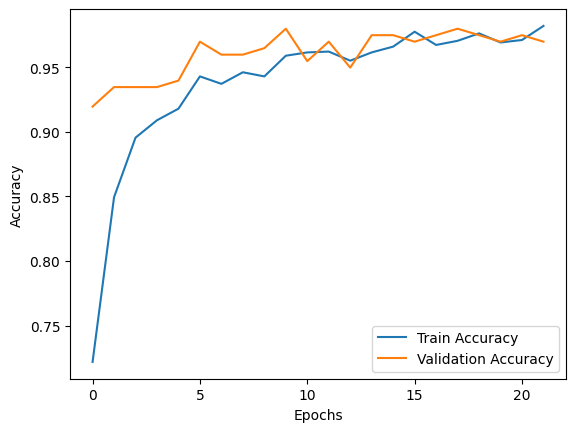

In [94]:
test_loss, test_accuracy = model.evaluate(x_test_generator)
print(f'Test accuracy: {test_accuracy * 100:.2f}%')

# Optional: Plot training history
plt.plot(his.history['accuracy'], label='Train Accuracy')
plt.plot(his.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [95]:
model.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 240, 240,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 120, 120,  │        432 │ input_layer_5[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 120, 120,  │         64 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 120, 120,  │          0 │ bn_Conv1[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 120, 120,  │        144 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 120, 120,  │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 120, 120,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 120, 120,  │        128 │ expanded_conv_de… │
│ (Conv2D)            │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 120, 120,  │         32 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 120, 120,  │        384 │ expanded_conv_pr… │
│ (Conv2D)            │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 120, 120,  │        192 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 120, 120,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 121, 121,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 60, 60,    │        432 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 60, 60,    │        192 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 60, 60,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 60, 60,    │        768 │ block_1_depthwis

 Total params: 1,827,605 (6.97 MB)

 Trainable params: 373,697 (1.43 MB)

 Non-trainable params: 706,512 (2.70 MB)

 Optimizer params: 747,396 (2.85 MB)

In [96]:
from tensorflow.keras.models import load_model
model1 = load_model('trash_classifier_mobilenetv28.h5')

In [97]:
test_loss, test_accuracy = model1.evaluate(x_test_generator)
print(f'Test accuracy: {test_accuracy * 100:.2f}%')

13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 119ms/step - accuracy: 0.9642 - loss: 0.1354
Test accuracy: 96.00%


In [98]:

model1_pred=model1.predict(x_test)
model1_pred_classes = (model1_pred > 0.5).astype(int)  # Use a threshold of 0.5
from sklearn.metrics import classification_report,confusion_matrix
cm = confusion_matrix(y_test,model1_pred_classes)
# Generate classification report
report = classification_report(y_test, model1_pred_classes)

print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", report)

7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 400ms/step
Confusion Matrix:
 [[94  6]
 [ 2 98]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.94      0.96       100
           1       0.94      0.98      0.96       100

    accuracy                           0.96       200
   macro avg       0.96      0.96      0.96       200
weighted avg       0.96      0.96      0.96       200

